# 16 - Fermionic QAOA (FQAOA)

This notebook provides a brief introduction to Fermionic QAOA (FQAOA). 
It shows how this technique is implemented in the OpenQAOA workflow by solving the constrained quadratic optimization problem, an NP-hard problem.

## A brief introduction

We present an implementation of a novel algorithm designed for solving combinatorial optimization problems with constraints, utilizing the principles of quantum computing. The algorithm, known as the FQAOA [[1](https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.5.023071)
, [2](https://arxiv.org/pdf/2312.04710)]
, introduces a significant enhancement over traditional methods by leveraging fermion particle number preservation. This intrinsic property allows the algorithm to enforce constraints naturally throughout the optimization process, addressing a critical challenge in many combinatorial problems.

### Key Features
- Constraint Handling: In contrast to conventional approaches, which treat constraints as soft constraints in the cost function, FQAOA enforces constraints intrinsically by preserving fermion particle numbers, thereby enhancing the overall performance of the optimization algorithm.

- Design of FQAOA Ansatz: In this algorithm,
the mixer is designed so that any classical state can be reached by its multiple actions.
The initial state is set to a ground state of the mixer Hamiltonian satisfying the constraints of the problem.

- Adiabatic Evolution: FQAOA effectively reduces to quantum adiabatic computation in the large limit of circuit depth, $p$, offering improved performance even for shallow circuits by optimizing parameters starting from fixed angles determined by Trotterized quantum adiabatic evolution.

- Performance Advantage: Extensive numerical simulations demonstrate that FQAOA offers substantial performance benefits over existing methods, particularly in portfolio optimization problems.

- Broad Applicability: The Hamiltonian design guideline benefits QAOA and extends to other algorithms like Grover adaptive search and quantum phase estimation, making it a versatile tool for solving constrained combinatorial optimization problems.

This notebook describes the implementation of FQAOA, illustrates its application through an example portfolio optimization problem, and provides insight into FQAOA's superior performance in constrained combinatorial optimization tasks.

### Quadratic Constrained Binary Optimization Problems
The constrained combinatorial optimization problem for a quadratic binary cost function $C_{\boldsymbol x}$ can be written in the following form：
$${\boldsymbol x}^* = \arg \min_{\boldsymbol x} C_{\boldsymbol x}\qquad {\rm s.t.} \quad\sum_{i=1}^{N} x_i = M,$$
with bit string ${\boldsymbol x}\in \{0,1\}^N$, where ${\boldsymbol x}^*$ is the optimal solution.
This problem can be replaced by the minimum eigenvalue problem in the following steps.

1. map the cost function $C_{\boldsymbol x}$ to the cost Hamiltonian $\hat{\cal H}_C$ by $x_i\rightarrow \hat{n}_i$:
\begin{eqnarray}
C_{\boldsymbol x} &=& \sum_i \mu_i x_{i}+\sum_{i,j} \sigma_{i,j} x_{i}x_{j}
&\quad\mapsto\quad&\hat{\cal H}_C=\sum_i \mu_i \hat{n}_{i}+\sum_{i,j} \sigma_{i,j} \hat{n}_{i_1}\hat{n}_{i_2},
\end{eqnarray}
where $\hat{n}_i = \hat{c}^\dagger_i\hat{c}_i$ is number operator and $\hat{c}_i^\dagger (\hat{c}_i)$ is creation (annihilation) operator of fermion at $i$-th site.

2. formulate eigenvalue problems for combinatorial optimization problem under the constraint:
\begin{eqnarray}
\hat{\cal H}_C|x_1x_2\cdots x_N\rangle &=& C_{\boldsymbol x}|x_1x_2\cdots x_N\rangle,\\
\sum_{i=1}^{N} \hat{n}_i|x_1x_2\cdots x_N\rangle &=& M|x_1x_2\cdots x_N\rangle,
\end{eqnarray}
where $|x_1x_2\cdots x_N\rangle=(\hat{c}^\dagger_1)^{x_1}(\hat{c}^\dagger_2)^{x_2}\cdots (\hat{c}^\dagger_N)^{x_N}|{\rm vac}\rangle$ is fermionic basis state and $|\rm vac\rangle$ is vacuum satisfying $\hat{c}_i|\rm vac\rangle=0$.

3. optimize FQAOA ansatz:
$$|\psi_p({\boldsymbol \gamma}^*, {\boldsymbol \beta}^*)\rangle 
= \left[\prod_{j=1}^pU(\hat{\cal H}_M,\beta_j^*){U}(\hat{\cal H}_C,\gamma_j^*)\right]\hat{U}_{\rm init}|{\rm vac}\rangle
\qquad {\rm by}\quad
C_p({\boldsymbol \gamma}^*, {\boldsymbol \beta}^*)=\min_{{\boldsymbol \gamma}, {\boldsymbol \beta}}C_p({\boldsymbol \gamma},{\boldsymbol \beta}),$$
$$\qquad{\rm where \quad}C_p({\boldsymbol \gamma}, {\boldsymbol \beta}) = \langle\psi_p({\boldsymbol \gamma}, {\boldsymbol \beta})|\hat{\cal H}_C|\psi_p({\boldsymbol \gamma}, {\boldsymbol \beta})\rangle.$$
The variational parameters $({\boldsymbol \gamma}^*, {\boldsymbol \beta}^*)$ give the lowest cost value at QAOA level $p$.


### One-Dimensional Mixer Hamiltonian

The FQAOA implemented on OpenQAOA employs mixer Hamiltonians on one-dimensional lattices. The main features of this computational model are summarized based on the study [[2]](https://arxiv.org/pdf/2312.04710):

- Utilises a mixer Hamiltonian on a one-dimensional lattice dedicated to combinatorial optimization problems with equality constraints of the same coefficients.

- Reduced Gate Operations: The new mixer Hamiltonian significantly reduces the number of gate operations in quantum circuits compared to previous studies [[1]](https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.5.023071), thus improving computational efficiency.

- Noise suppression: as demonstrated in a 16-qubit trapped-ion quantum computer on Amazon Braket, the proposed mixer Hamiltonian effectively suppresses noise and improves algorithm performance.

As these features enhance the performance and reliability of FQAOA for solving constrained combinatorial optimization problems, we focus on FQAOA with one-dimensional mixer Hamiltonians.

The specific mixer Hamiltonian $\hat{\cal H}_M$ on cyclic lattice to be implemented in OpenQAOA are as follow:

\begin{eqnarray}
\hat{\cal H}_M &=& -t\sum_{i=1}^{N-1} (\hat{c}^\dagger_i\hat{c}_{i+1}+\hat{c}^\dagger_{i+1}\hat{c}_i)-t(-1)^{M-1}(\hat{c}^\dagger_N\hat{c}_{1}+\hat{c}^\dagger_{1}\hat{c}_N).
\end{eqnarray}
These Hamiltonians can be diagonalized as:
$$\hat{\cal H}_M=\sum_{i=1}^{N}\varepsilon_i\hat{\gamma}_i^\dagger\hat{\gamma}_i \qquad {\rm with} \quad
\hat{\gamma}_i^\dagger = \sum_{j=1}^N[\phi_0]_{i,j}\hat{c}^\dagger_j,$$
where $[\phi_0]$ is the unitary matrix used for the diagonalization and $\varepsilon_i$ is eigenvalue.
The formulation and validation of the model on cyclic lattice are detailed in the study [[2]](https://arxiv.org/pdf/2312.04710).

### Initial State and Mixer for FQAOA

We describe the specific calculation model utilized for our implementation of the FQAOA on cyclic lattice. 
The initial state preparation unitary $\hat{U}_{\rm init}$ and the mixer $\hat{U}_M$ used to implement the FQAOA are shown below.

- initial state preparation unitary $\hat{U}_{\rm init}$ on cyclic lattice:
$$|\phi_0\rangle=\hat{U}_{\rm init}|{\rm vac}\rangle=\left(\prod_{i=1}^{M}\hat{\gamma}_i^\dagger\right)|{\rm vac}\rangle,
\qquad{\rm with}\quad \hat{U}_{\rm init}=\prod_{i=1}^{M}\left(\sum_{j=1}^N[\phi_0]_{i,j}\hat{c}^\dagger_j\right),$$
where $M$ is the number of fermions and $i$ indexes the eigenvalues $\varepsilon_i$ in ascending order.
The implementation of the initial state preparation unitary on quantum circuit are shown in Refs. [[1](https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.5.023071),[2](https://arxiv.org/pdf/2312.04710),[3](https://arxiv.org/pdf/1711.05395)].

- mixing unitary $U(\hat{\cal H}_M, \beta)$ on cyclic lattice:
\begin{eqnarray}
U(\hat{\cal H}_M, \beta) &\sim&
\exp\left[i\beta t(-1)^{M-1}\left(\hat{c}^{\dagger}_{ND}\hat{c}_{1}+\hat{c}^{\dagger}_{1}\hat{c}_{ND}\right)\right]\\&&\times
\prod_{i\ {\rm even}}\exp\left[i\beta t\left(\hat{c}^{\dagger}_i\hat{c}_{i+1}+\hat{c}^{\dagger}_{i+1}\hat{c}_{i}\right)\right]
\prod_{i\ {\rm odd}}\exp\left[i\beta t\left(\hat{c}^{\dagger}_i\hat{c}_{i+1}+\hat{c}^{\dagger}_{i+1}\hat{c}_{i}\right)\right],
\end{eqnarray}
where the approximation by Trotter decomposition is applied, as certain hopping terms are non-commutative.
The implementation of the mixer unitary indicated on the right-hand side on quantum circuits is given in Refs. [[1](https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.5.023071),
[2](https://arxiv.org/pdf/2312.04710), [4](https://arxiv.org/pdf/1709.03489), [5](https://arxiv.org/pdf/1904.09314)].

In [1]:
%matplotlib notebook
%matplotlib inline

# Import the libraries needed to employ the QAOA and FQAOA quantum algorithm using OpenQAOA
from openqaoa import FQAOA
from openqaoa import QAOA

# method to covnert a docplex model to a qubo problem
from openqaoa.problems import PortfolioOptimization

# Import external libraries to present an manipulate the data
import pandas as pd
import matplotlib.pyplot as plt

## Portfolio Optimization

In the following, the [portfolio optimization problem](https://en.wikipedia.org/wiki/Portfolio_optimization) is taken as a constrained quadratic optimization problem.
Start by creating an instance of the portfolio optimization problem, using the `random_instance` method of the `PortfolioOptimization`.

In [2]:
# create a problem instance for portfolio optimization
num_assets = 4 # number of decision variables
budget = 2 # constraint on the sum of decision variables
problem = PortfolioOptimization.random_instance(num_assets=num_assets, budget=budget).qubo

##  Solving the problem

The simplest QAOA and FQAOA workflows.

In [3]:
# conventional QAOA workflow
qaoa = QAOA()
qaoa.compile(problem = problem)
qaoa.optimize()

In [4]:
# FQAOA workflow
fqaoa = FQAOA()
fqaoa.compile(problem = problem, n_fermions = budget)
fqaoa.optimize()

## Performance Evaluation of FQAOA
To evaluate the performance of FQAOA, we show expectation value of costs. 

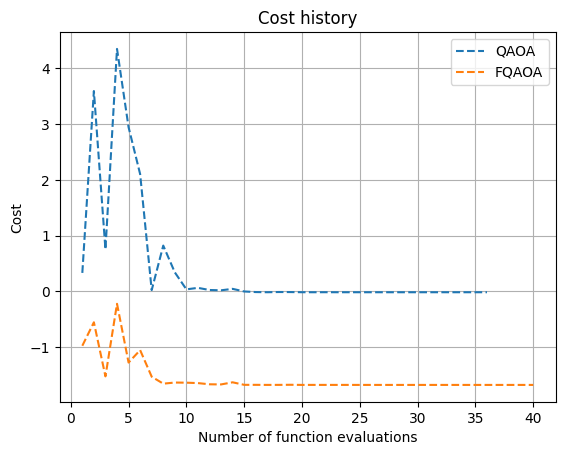

In [5]:
labels = ['QAOA', 'FQAOA']

# plot cost history
fig, ax = plt.subplots()
for i, result in enumerate([qaoa.result, fqaoa.result]):
    result.plot_cost(ax=ax, color=f'C{i}', label=labels[i])
ax.grid(True)
plt.show()

In [6]:
# evaluate optimized expectation values of the cost
exp_cost_dict = {
    'Method': labels,
    r'Optimized Cost $\langle C_{\boldsymbol x} \rangle$':[qaoa.result.optimized['cost'], fqaoa.result.optimized['cost']]
}
df = pd.DataFrame(exp_cost_dict)
print('optimized expectation values of the cost')
display(df)

optimized expectation values of the cost


,Method,Optimized Cost $\langle C_{\boldsymbol x} \rangle$
0,QAOA,-0.014343
1,FQAOA,-1.675643


In [7]:
# Print the best 5 solutions
qaoa_lowest5_dict = qaoa.result.lowest_cost_bitstrings(5)
fqaoa_lowest5_dict = fqaoa.result.lowest_cost_bitstrings(5)

qaoa_dict = {
    r'Bitstring, $\boldsymbol{x}$': qaoa_lowest5_dict['solutions_bitstrings'],
    r'Cost, $C_{\boldsymbol x}$': qaoa_lowest5_dict['bitstrings_energies'],
    labels[0]: qaoa_lowest5_dict['probabilities'],
    labels[1]: fqaoa_lowest5_dict['probabilities']
}
df = pd.DataFrame(qaoa_dict)
print('probabilities of finding the best five optimal solutions')
display(df)

probabilities of finding the best five optimal solutions


,"Bitstring, $\boldsymbol{x}$","Cost, $C_{\boldsymbol x}$",QAOA,FQAOA
0,1010,-1.797905,0.144896,0.904789
1,1100,-0.720493,0.124931,0.015386
2,0110,-0.602018,0.122931,0.033298
3,1001,-0.471908,0.120777,0.031587
4,0011,-0.362333,0.119113,0.012593


## References

[1] T. Yoshioka, K. Sasada, Y. Nakano, and K. Fujii, [Phys. Rev. Research 5, 023071 (2023).](https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.5.023071), [arXiv:2301.10756 [quant-ph]](https://arxiv.org/pdf/2301.10756).\
[2] T. Yoshioka, K. Sasada, Y. Nakano, and K. Fujii, [2023 IEEE International Conference on Quantum Computing and Engineering (QCE) 1, 300-306 (2023).](https://ieeexplore.ieee.org/document/10313662), [arXiv:2312.04710 [quant-ph]](https://arxiv.org/pdf/2312.04710).\
[3] Z. Jiang, J. S. Kevin, K. Kechedzhi, V. N. Smelyanskiy, and S. Boixo, [Phys. Rev. Appl. 9, 044036 (2018).](https://journals.aps.org/prapplied/abstract/10.1103/PhysRevApplied.9.044036)[arXiv:1711.05395 [quant-ph]](https://arxiv.org/pdf/1711.05395).\
[4] S. Hadfield, Z. Wang, B. O’Gorman, E. G. Rieffel, D. Venturelli, and R. Biswas, [algorithms 12, 34 (2019).](https://www.mdpi.com/1999-4893/12/2/34),[arXiv:1709.03489v2 [quant-ph]](https://arxiv.org/pdf/1709.03489).\
[5] Z. Wang, N. C. Rubin, J. M. Dominy, and E. G. Rioeffel, [Phys. Rev. A 101, 012320 (2020).](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.101.012320),[arXiv:1904.09314v2 [quant-ph]](https://arxiv.org/pdf/1904.09314).